In [38]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import FunctionTransformer, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import make_column_transformer
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    IsolationForest,
)
from sklearn.neighbors import KNeighborsRegressor
from scipy.stats import randint, uniform
from sklearn.ensemble import HistGradientBoostingRegressor

random_state = 42
np.random.seed(random_state)

In [39]:
pd.set_option('display.max_columns', None)

df = pd.read_csv('../../data/processed_player_data_v2.csv')

df.head()


,Game ID,player_rating,opponent_rating,player_white,opening_ply,elo_delta_ratio,opening_frequency,player_centipawn_loss,opponent_centipawn_loss,time_control,time_control_encoded,player_username,opponent_username,opening_familiarity,player_rapid_rating,opponent_rapid_rating,player_rapid_games,opponent_rapid_games,player_blitz_rating,opponent_blitz_rating,player_blitz_games,opponent_blitz_games,player_bullet_rating,opponent_bullet_rating,player_bullet_games,opponent_bullet_games,player_total_games,opponent_total_games,player_play_time_secs,opponent_play_time_secs,player_avg_game_secs,opponent_avg_game_secs,player_blitz_vs_rapid,player_bullet_vs_blitz,player_bullet_vs_rapid,opponent_blitz_vs_rapid,opponent_bullet_vs_blitz,opponent_bullet_vs_rapid,player_rapid_ratio,player_blitz_ratio,player_bullet_ratio,opponent_rapid_ratio,opponent_blitz_ratio,opponent_bullet_ratio,rapid_rating_gap,blitz_rating_gap,total_games_gap,rapid_games_gap,play_time_gap
0,J7Xvjkte,1441,1559,1,4,-0.078667,2,32,87,rapid,3,jerzypa2,timothei,1,1467.0,1659.0,965,2657,1155.0,1385.0,142,952,982.0,1018.0,26,8,1251,3980,1016708,3090613,812.716227,776.535930,-312.0,-173.0,-485.0,-274.0,-367.0,-641.0,0.771383,0.113509,0.020783,0.667588,0.239196,0.002010,-192.0,-230.0,-2729,-1692,-2073905
1,SSzpi7W1,1258,1567,1,6,-0.218761,2,43,6,rapid,3,nephi,veky,1,1221.0,1689.0,261,3466,1184.0,1393.0,6,9327,1284.0,1500.0,3,4452,333,18177,272224,6513529,817.489489,358.339055,-37.0,100.0,63.0,-296.0,107.0,-189.0,0.783784,0.018018,0.009009,0.190681,0.513121,0.244925,-468.0,-209.0,-17844,-3205,-6241305
2,NHpcYm3r,1697,1712,1,7,-0.008800,2,11,42,rapid,3,ronuh,kuramateca,1,NaN,1573.0,0,9230,NaN,1357.0,0,119,NaN,1330.0,0,2,0,9358,0,7732082,NaN,826.253687,NaN,NaN,NaN,-216.0,-27.0,-243.0,NaN,NaN,NaN,0.986322,0.012716,0.000214,NaN,NaN,-9358,-9230,-7732082
3,Nrzmgzmn,1978,1868,1,5,0.057202,2,21,53,rapid,3,anaya44,jeoda,1,NaN,1786.0,0,2172,NaN,1640.0,0,29436,NaN,955.0,0,1,0,31613,0,16836309,NaN,532.575491,NaN,NaN,NaN,-146.0,-685.0,-831.0,NaN,NaN,NaN,0.068706,0.931136,0.000032,NaN,NaN,-31613,-2172,-16836309
4,xMuFsnC6,2073,1816,1,2,0.132168,2,35,50,rapid,3,marc_robin,deraincharles,1,2158.0,2029.0,226,790,2119.0,1841.0,31948,2351,1500.0,1609.0,0,1357,32177,4567,14125375,1843793,438.989806,403.720823,-39.0,-619.0,-658.0,-188.0,-232.0,-420.0,0.007024,0.992883,0.000000,0.172980,0.514780,0.297132,129.0,278.0,27610,-564,12281582


In [40]:
df = df.drop(columns=['Game ID', 'player_username', 'opponent_username', 'time_control','time_control_encoded','opponent_centipawn_loss'])
rating_cols = ['player_rapid_rating', 'player_blitz_rating', 'player_bullet_rating']
opponent_rating_cols = ['opponent_rapid_rating', 'opponent_blitz_rating', 'opponent_bullet_rating']

df['player_profile_disabled']   = df[rating_cols].isnull().any(axis=1).astype(int)
df['opponent_profile_disabled']  = df[opponent_rating_cols].isnull().any(axis=1).astype(int)

df_original = df.copy()
df_original_copy =df.copy()
df_original_2 =df.copy()

In [11]:
df.columns #45 columns

Index(['player_rating', 'opponent_rating', 'player_white', 'opening_ply',
       'elo_delta_ratio', 'opening_frequency', 'player_centipawn_loss',
       'opening_familiarity', 'player_rapid_rating', 'opponent_rapid_rating',
       'player_rapid_games', 'opponent_rapid_games', 'player_blitz_rating',
       'opponent_blitz_rating', 'player_blitz_games', 'opponent_blitz_games',
       'player_bullet_rating', 'opponent_bullet_rating', 'player_bullet_games',
       'opponent_bullet_games', 'player_total_games', 'opponent_total_games',
       'player_play_time_secs', 'opponent_play_time_secs',
       'player_avg_game_secs', 'opponent_avg_game_secs',
       'player_blitz_vs_rapid', 'player_bullet_vs_blitz',
       'player_bullet_vs_rapid', 'opponent_blitz_vs_rapid',
       'opponent_bullet_vs_blitz', 'opponent_bullet_vs_rapid',
       'player_rapid_ratio', 'player_blitz_ratio', 'player_bullet_ratio',
       'opponent_rapid_ratio', 'opponent_blitz_ratio', 'opponent_bullet_ratio',
       'rapid

# Feature Distributions & Relationships

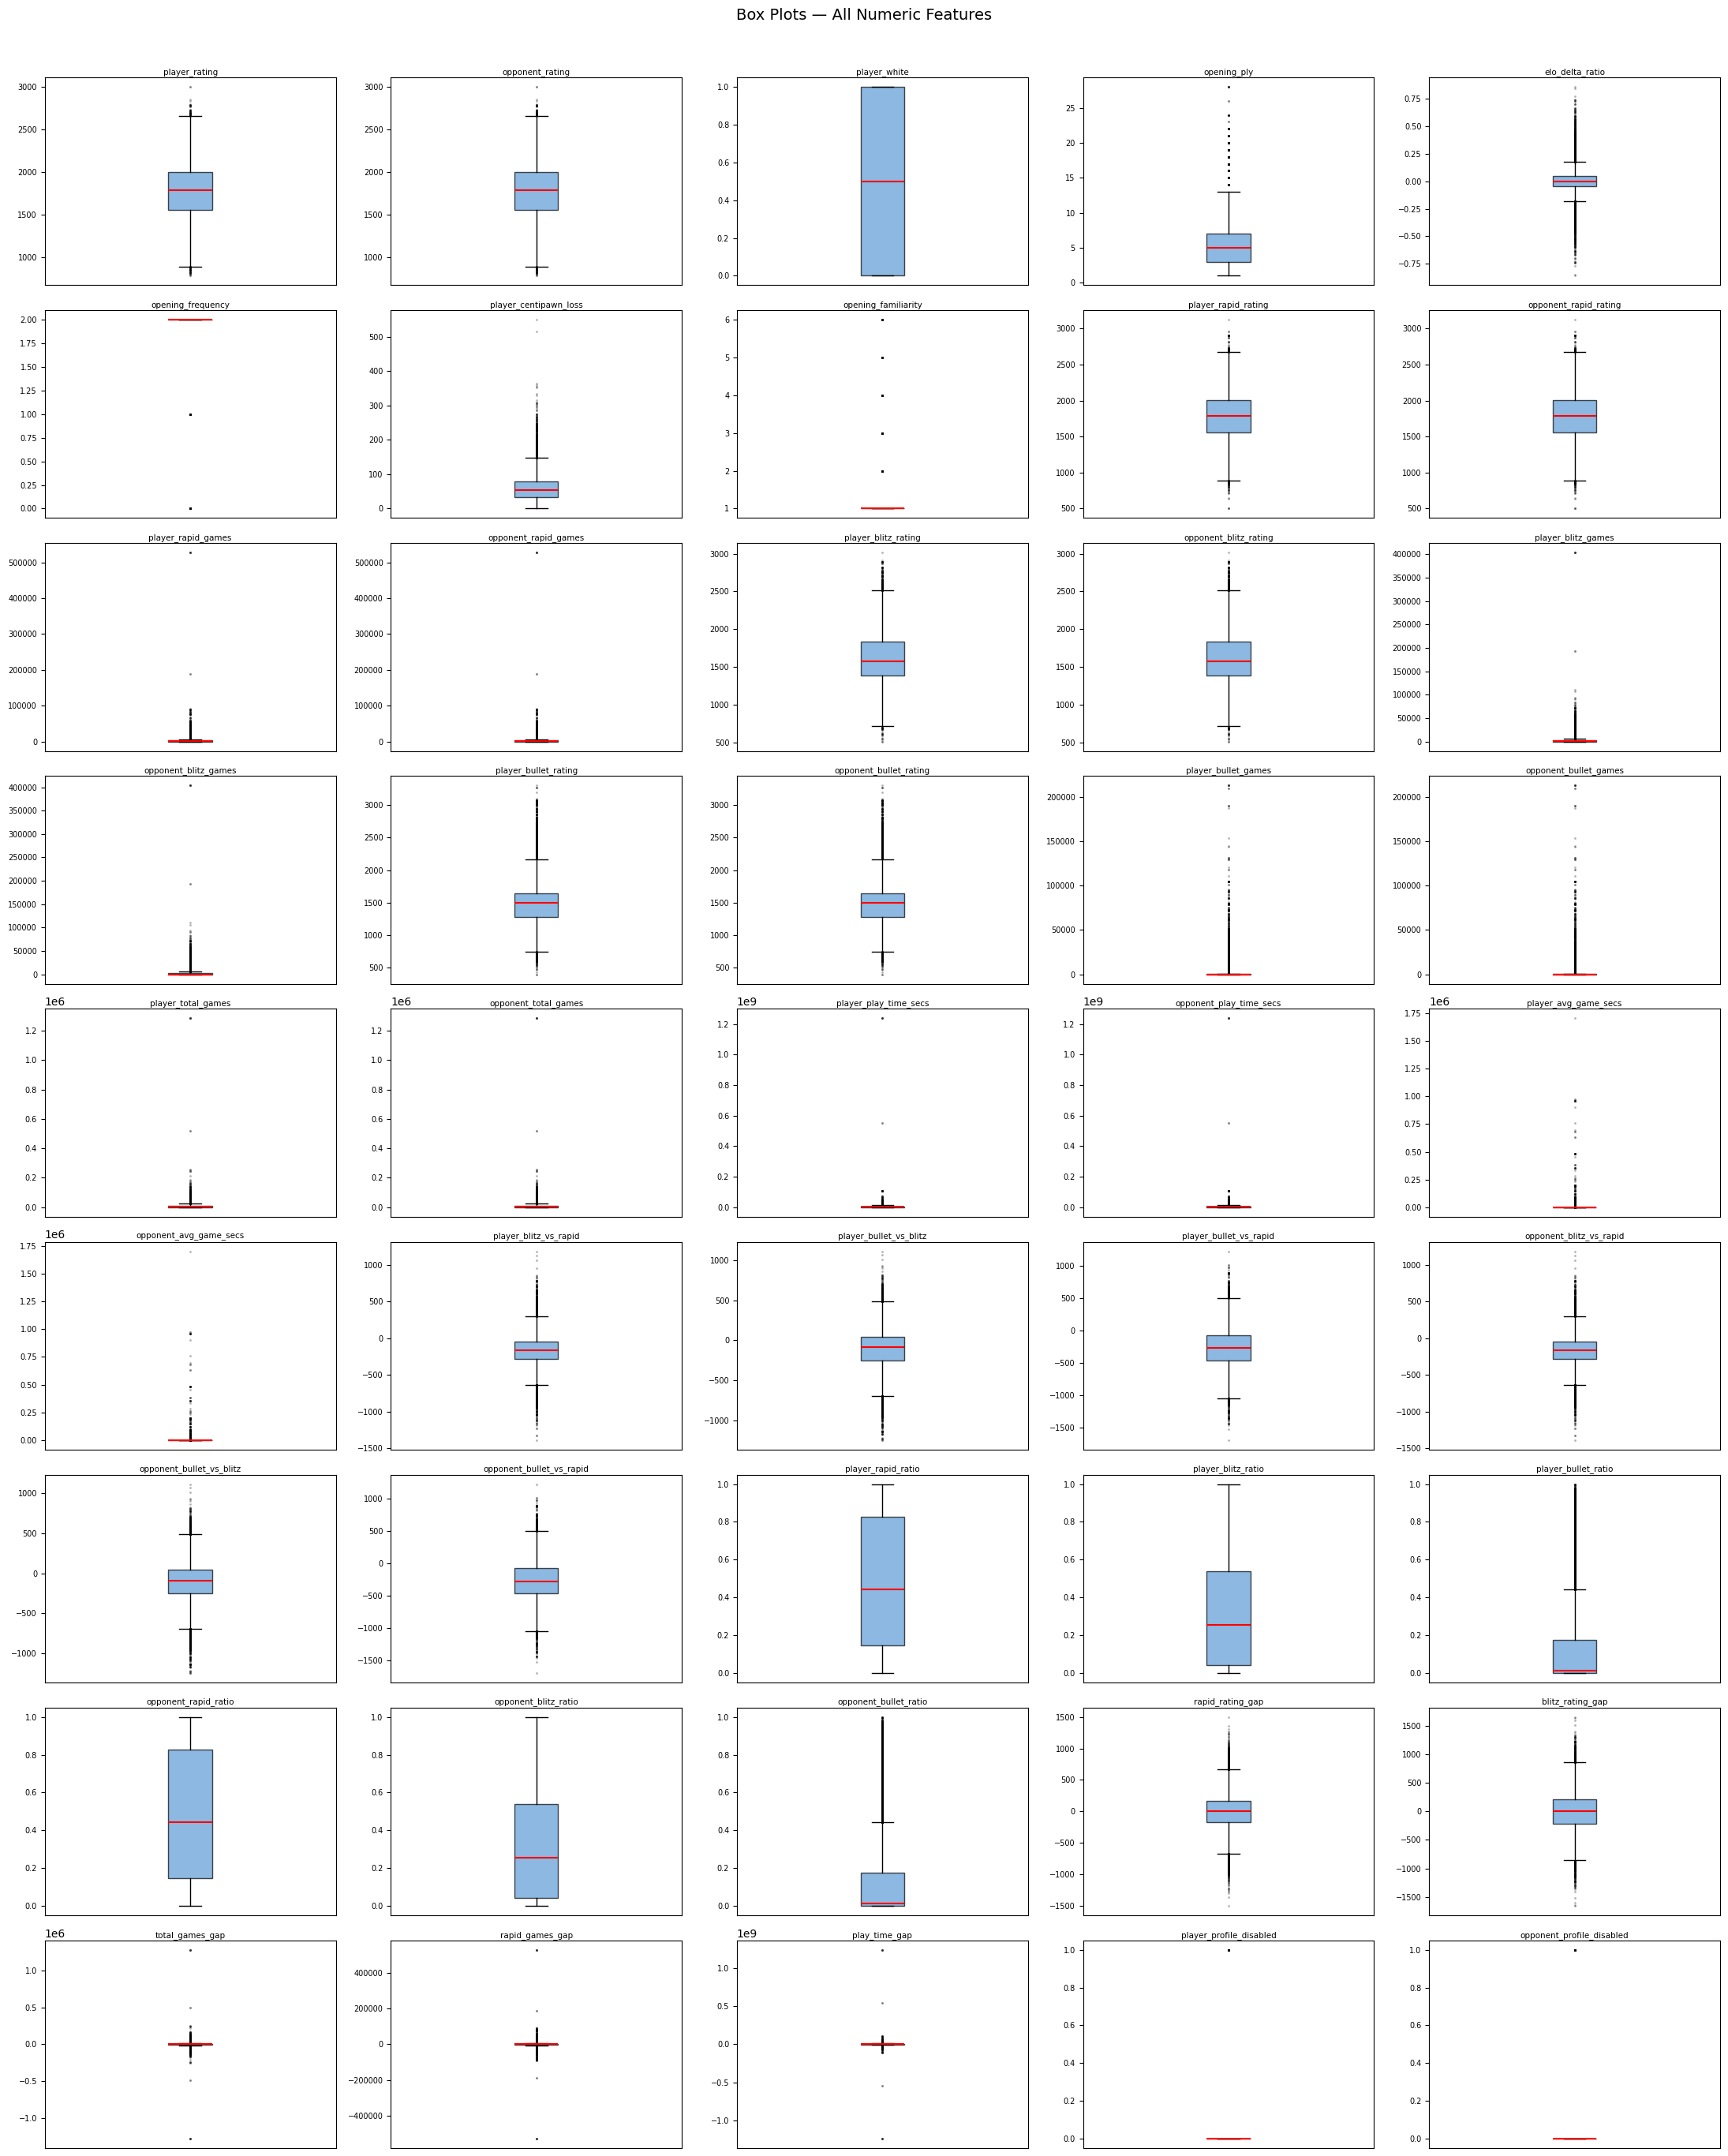

In [12]:
# Box plots for all numeric features
numeric_cols_bp = df.select_dtypes(include='number').columns.tolist()

n_cols = 5
n_rows = (len(numeric_cols_bp) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(22, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(numeric_cols_bp):
    data = df[col].dropna()
    axes[i].boxplot(
        data, vert=True, patch_artist=True,
        boxprops=dict(facecolor='#5b9bd5', alpha=0.7),
        medianprops=dict(color='red', linewidth=1.5),
        flierprops=dict(marker='.', markersize=2, alpha=0.3),
        whiskerprops=dict(linewidth=1),
        capprops=dict(linewidth=1),
    )
    axes[i].set_title(col, fontsize=7.5, pad=3)
    axes[i].tick_params(axis='x', bottom=False, labelbottom=False)
    axes[i].tick_params(axis='y', labelsize=7)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Box Plots — All Numeric Features', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

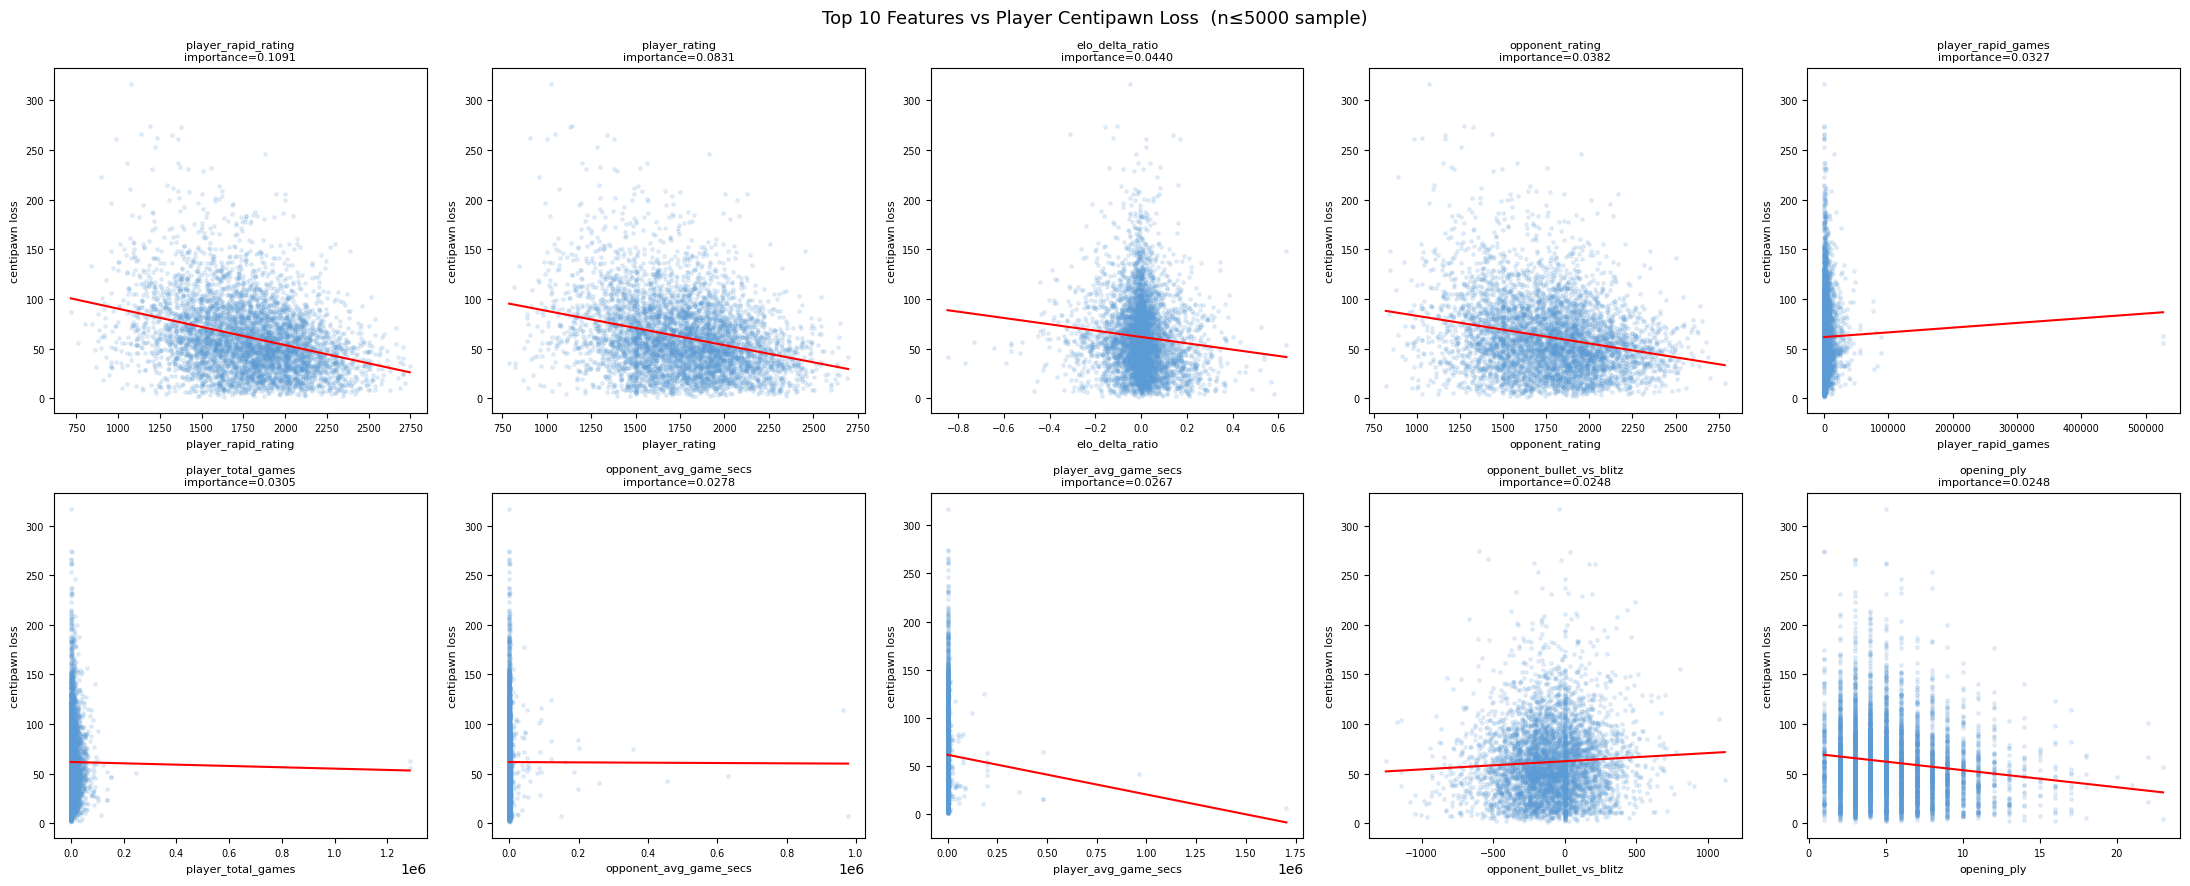

In [13]:
# 1:1 scatter plots: top 10 most important features vs player_centipawn_loss
top_10_feats = [
    ('player_rapid_rating',    0.109132),
    ('player_rating',          0.083118),
    ('elo_delta_ratio',        0.044034),
    ('opponent_rating',        0.038168),
    ('player_rapid_games',     0.032700),
    ('player_total_games',     0.030537),
    ('opponent_avg_game_secs', 0.027848),
    ('player_avg_game_secs',   0.026652),
    ('opponent_bullet_vs_blitz', 0.024846),
    ('opening_ply',            0.024773),
]

n_sample = min(5000, len(df))
feat_names = [f for f, _ in top_10_feats]
sample_df = df[feat_names + ['player_centipawn_loss']].dropna().sample(n_sample, random_state=random_state)

fig, axes = plt.subplots(2, 5, figsize=(22, 9))
axes = axes.flatten()

for i, (feat, importance) in enumerate(top_10_feats):
    x = sample_df[feat]
    y = sample_df['player_centipawn_loss']
    axes[i].scatter(x, y, alpha=0.15, s=6, color='#5b9bd5')
    m, b = np.polyfit(x, y, 1)
    xline = np.linspace(x.min(), x.max(), 200)
    axes[i].plot(xline, m * xline + b, color='red', linewidth=1.5)
    axes[i].set_xlabel(feat, fontsize=8)
    axes[i].set_ylabel('centipawn loss', fontsize=8)
    axes[i].set_title(f'{feat}\nimportance={importance:.4f}', fontsize=8)
    axes[i].tick_params(labelsize=7)

plt.suptitle(f'Top 10 Features vs Player Centipawn Loss  (n≤{n_sample} sample)', fontsize=13)
plt.tight_layout()
plt.show()

The graphs that seem to have data look like straight line to the left, are graphs of data with huge outliers. Look at for exmaple the graph of centpawnloss vs player_rapid_rating: <br>
Most of the players have probably around 0-1000 games. But there are two outliers with more than HALF A MILLION games. Idk how is that even possible. This is equivalent of playing around 7k hours of online chess assuming these are 10 minutes games.

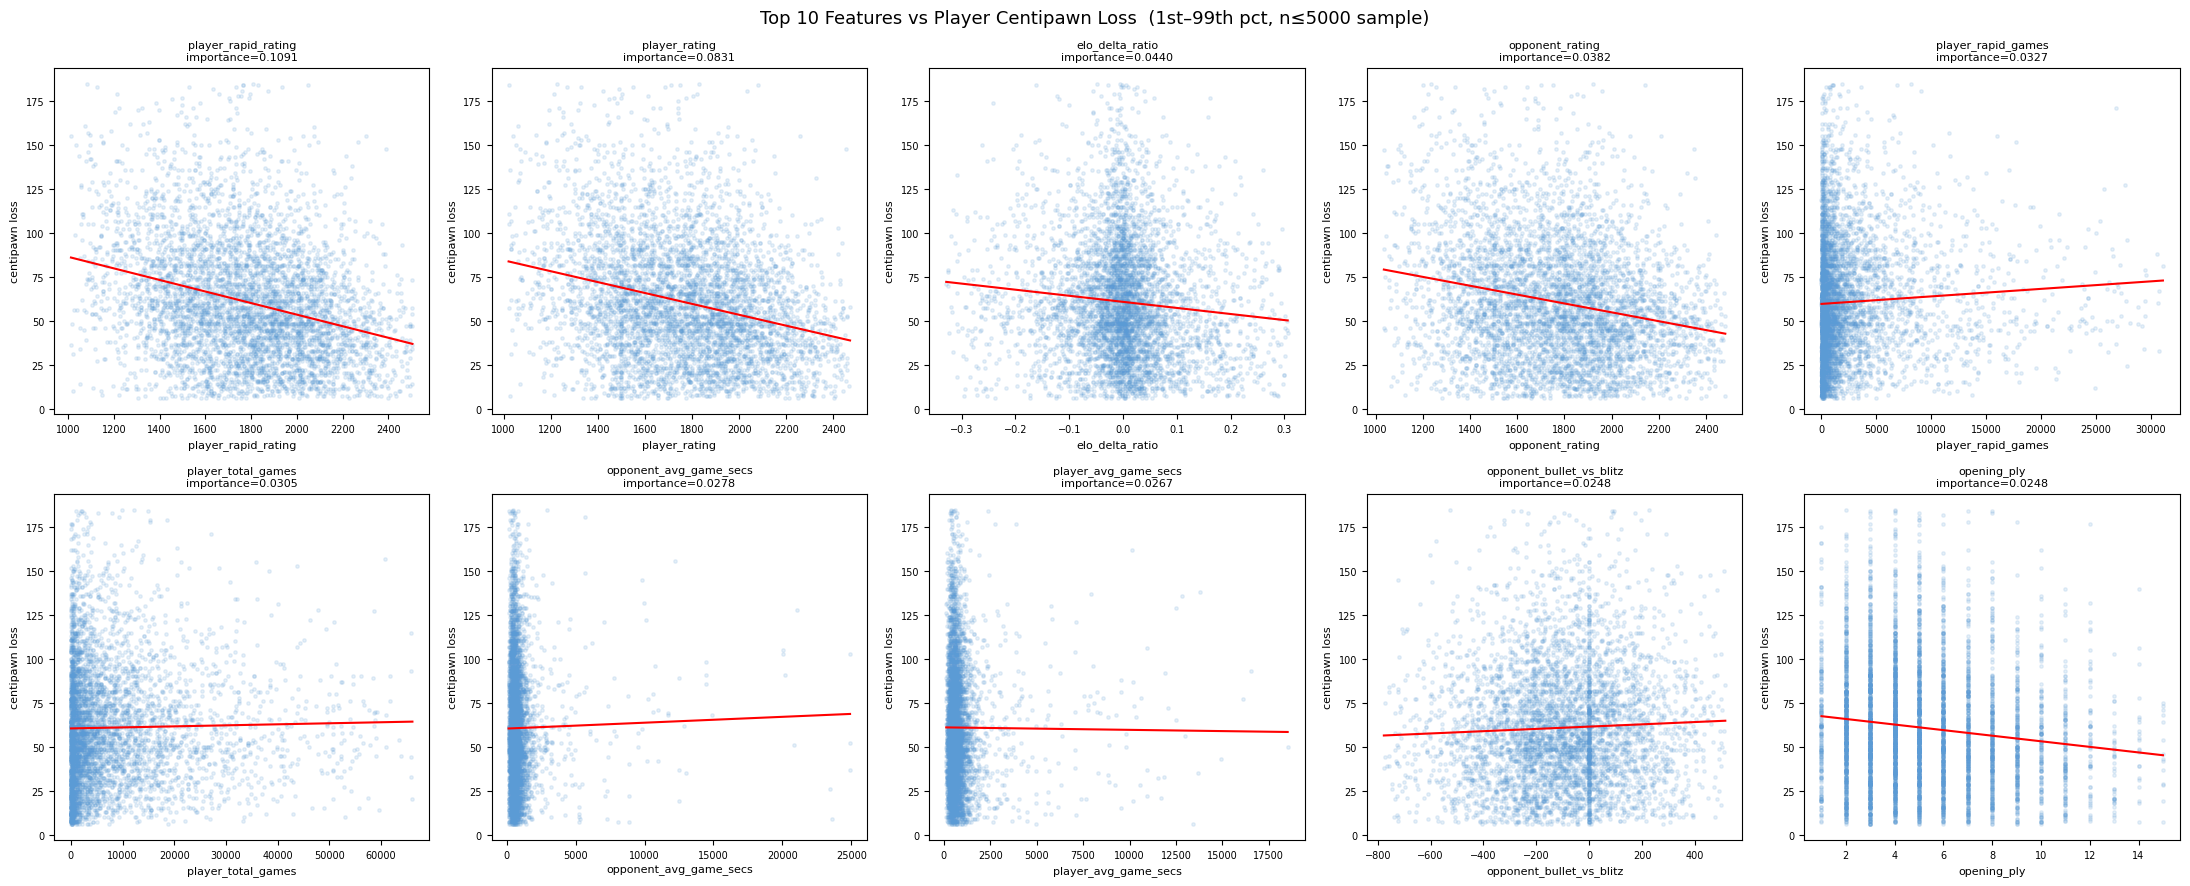

In [14]:
# 1:1 scatter plots: top 10 most important features vs player_centipawn_loss
top_10_feats = [
    ('player_rapid_rating',    0.109132),
    ('player_rating',          0.083118),
    ('elo_delta_ratio',        0.044034),
    ('opponent_rating',        0.038168),
    ('player_rapid_games',     0.032700),
    ('player_total_games',     0.030537),
    ('opponent_avg_game_secs', 0.027848),
    ('player_avg_game_secs',   0.026652),
    ('opponent_bullet_vs_blitz', 0.024846),
    ('opening_ply',            0.024773),
]

n_sample = min(5000, len(df))
feat_names = [f for f, _ in top_10_feats]
sample_df = df[feat_names + ['player_centipawn_loss']].dropna().sample(n_sample, random_state=random_state)

fig, axes = plt.subplots(2, 5, figsize=(22, 9))
axes = axes.flatten()

for i, (feat, importance) in enumerate(top_10_feats):
    x = sample_df[feat]
    y = sample_df['player_centipawn_loss']

    x_lo, x_hi = np.percentile(x, [1, 99])
    y_lo, y_hi = np.percentile(y, [1, 99])

    mask = (x >= x_lo) & (x <= x_hi) & (y >= y_lo) & (y <= y_hi)
    x_cl, y_cl = x[mask], y[mask]

    axes[i].scatter(x_cl, y_cl, alpha=0.15, s=6, color='#5b9bd5')
    m, b = np.polyfit(x_cl, y_cl, 1)
    xline = np.linspace(x_cl.min(), x_cl.max(), 200)
    axes[i].plot(xline, m * xline + b, color='red', linewidth=1.5)
    axes[i].set_xlabel(feat, fontsize=8)
    axes[i].set_ylabel('centipawn loss', fontsize=8)
    axes[i].set_title(f'{feat}\nimportance={importance:.4f}', fontsize=8)
    axes[i].tick_params(labelsize=7)

plt.suptitle(f'Top 10 Features vs Player Centipawn Loss  (1st–99th pct, n≤{n_sample} sample)', fontsize=13)
plt.tight_layout()
plt.show()

These are graphs that show most of the data and do not show outliers

# Outlier Removal (IQR, Box Plot Method)

If certain row has 

In [15]:
df_clean = df.copy()

# Skip binary or flag or target columns, only apply IQR to continuous features
skip_iqr = {'player_white', 'player_profile_disabled', 'opponent_profile_disabled',
            'opening_familiarity', 'opening_frequency', 'player_centipawn_loss'}
iqr_cols = [c for c in df_clean.select_dtypes(include='number').columns if c not in skip_iqr]

outlier_count = np.zeros(len(df_clean), dtype=int)
for col in iqr_cols:
    q1, q3 = df_clean[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    is_out = df_clean[col].notna() & ~df_clean[col].between(lo, hi)
    outlier_count += is_out.to_numpy().astype(int)

#what it does is just counting how many features are outliers for each row, then removing rows that have too many outlier features. This way we can keep rows that have a few outlier values but not remove them entirely if they are mostly normal. It's a more flexible way to handle outliers without being too strict on any single feature.
#Also I checked different thresholds 
threshold = 3
mask = outlier_count <= threshold
df_clean = df_clean[mask].reset_index(drop=True)
n_removed = int((~mask).sum())

print(f"Rows before : {len(df):>6}")
print(f"Rows after  : {len(df_clean):>6}")
print(f"Removed     : {n_removed:>6}  ({n_removed / len(df) * 100:.1f}%)")

Rows before :  37274
Rows after  :  26856
Removed     :  10418  (27.9%)


threshold=10 =>  CV RMSE:    34.21 Amount of data removed (0.9%) <br>
threshold=9 =>  CV RMSE:     34.52 Amount of data removed (2.0%) <br>
threshold=8 =>  CV RMSE:     34.52 Amount of data removed (3.7%) <br>
threshold=7 =>  CV RMSE:     34.58 Amount of data removed (6.6%) <br>
threshold=6 =>  CV RMSE:     34.76 Amount of data removed (10.7%)<br>
threshold=3 =>  CV RMSE:     35.17 Amount of data removed (27.9%)<br>
threshold=2 =>  CV RMSE:     35.54 Amount of data removed (37.5%)<br>
threshold=1 =>  CV RMSE:     35.81 Amount of data removed (54.7%)<br>

In [16]:
X = df_clean.drop(columns=['player_centipawn_loss'])
y = df_clean['player_centipawn_loss']

In [17]:
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.2, random_state=42)

In [42]:
kf = KFold(n_splits=5, shuffle=True, random_state=random_state)

In [19]:
pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model',  HistGradientBoostingRegressor(max_iter=200, random_state=random_state)),
    ])

param_dist = {
    'model__max_iter':      randint(100, 400),
    'model__max_depth':     randint(3, 8),
    'model__learning_rate': uniform(0.01, 0.3),
}

search = RandomizedSearchCV(pipeline, param_dist, n_iter=30, cv=kf,
                             scoring='neg_root_mean_squared_error', n_jobs=-1,
                             random_state=random_state)

search.fit(X_train_val, y_train_val)

print(f"Best params: {search.best_params_}")
print(f"CV RMSE:     {-search.best_score_:.2f}")

Best params: {'model__learning_rate': np.float64(0.027425083650459835), 'model__max_depth': 7, 'model__max_iter': 199}
CV RMSE:     35.17


After trying out different threshold we can see that the higher the threshold, the lower the RMSE.
The CV RMse is the lowest when threshold reults in deleting 0% of the data

I have an idea of just nulling out outliers and then imputing median

In [20]:
# Alternative: null out outlier values instead of dropping rows, let imputer fill them
df_clean_nulled = df.copy()

nulled = 0
for col in iqr_cols:
    q1, q3 = df_clean_nulled[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    mask = df_clean_nulled[col].notna() & ~df_clean_nulled[col].between(lo, hi)
    nulled += mask.sum()
    df_clean_nulled.loc[mask, col] = np.nan

print(f"Rows: {len(df_clean_nulled)}  (unchanged)")
print(f"Values nulled: {nulled}  (will be imputed with median in pipeline)")

Rows: 37274  (unchanged)
Values nulled: 95060  (will be imputed with median in pipeline)


In [21]:
X = df_clean_nulled.drop(columns=['player_centipawn_loss'])
y = df_clean_nulled['player_centipawn_loss']

X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.2, random_state=42)

In [22]:
pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model',  HistGradientBoostingRegressor(max_iter=200, random_state=random_state)),
    ])

param_dist = {
    'model__max_iter':      randint(100, 400),
    'model__max_depth':     randint(3, 8),
    'model__learning_rate': uniform(0.01, 0.3),
}

search = RandomizedSearchCV(pipeline, param_dist, n_iter=30, cv=kf,
                             scoring='neg_root_mean_squared_error', n_jobs=-1,
                             random_state=random_state)

search.fit(X_train_val, y_train_val)

print(f"Best params: {search.best_params_}")
print(f"CV RMSE:     {-search.best_score_:.2f}")

Best params: {'model__learning_rate': np.float64(0.05680559213273095), 'model__max_depth': 5, 'model__max_iter': 314}
CV RMSE:     34.34


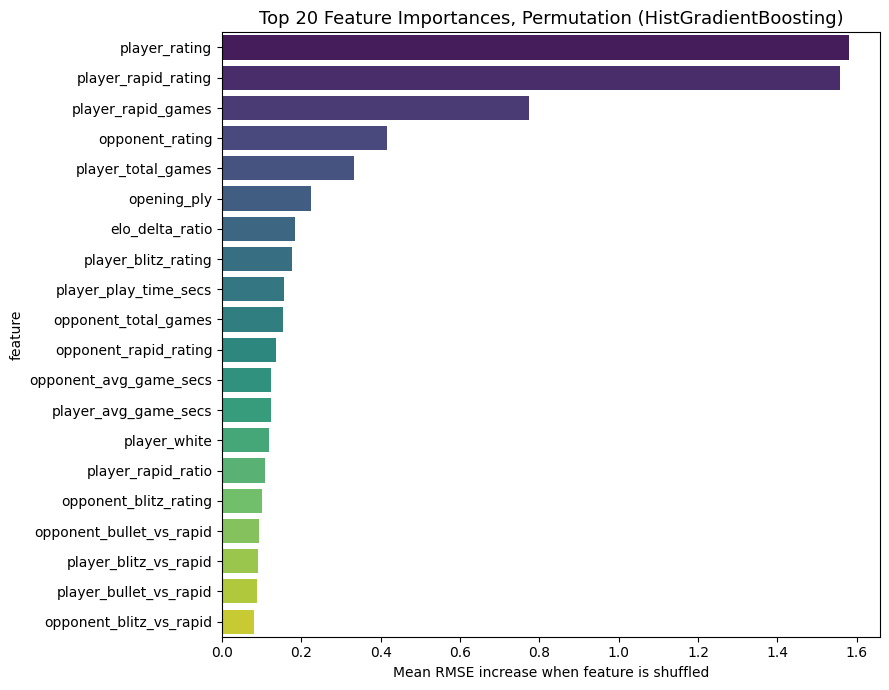

                 feature  importance
           player_rating    1.579980
     player_rapid_rating    1.558875
      player_rapid_games    0.772727
         opponent_rating    0.416929
      player_total_games    0.331347
             opening_ply    0.223648
         elo_delta_ratio    0.182522
     player_blitz_rating    0.176942
   player_play_time_secs    0.155522
    opponent_total_games    0.152192
   opponent_rapid_rating    0.134754
  opponent_avg_game_secs    0.123044
    player_avg_game_secs    0.122056
            player_white    0.117948
      player_rapid_ratio    0.108348
   opponent_blitz_rating    0.101160
opponent_bullet_vs_rapid    0.093641
   player_blitz_vs_rapid    0.089701
  player_bullet_vs_rapid    0.087240
 opponent_blitz_vs_rapid    0.080545


In [23]:
from sklearn.inspection import permutation_importance

# Permutation importance — works with any estimator
perm = permutation_importance(
    search.best_estimator_, X_train_val, y_train_val,
    n_repeats=5, random_state=random_state, n_jobs=-1,
    scoring='neg_root_mean_squared_error',
)

fi_df = pd.DataFrame({
    'feature':    X_train_val.columns,
    'importance': perm.importances_mean,
}).sort_values('importance', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(9, 7))
sns.barplot(data=fi_df, x='importance', y='feature',
            hue='feature', legend=False, ax=ax, palette='viridis')
ax.set_title('Top 20 Feature Importances, Permutation (HistGradientBoosting)', fontsize=13)
ax.set_xlabel('Mean RMSE increase when feature is shuffled')
plt.tight_layout()
plt.show()
print(fi_df.to_string(index=False))

Explained variance ratio (top 10 PCs):
  PC1: 0.131   cumulative: 0.131
  PC2: 0.093   cumulative: 0.224
  PC3: 0.070   cumulative: 0.294
  PC4: 0.063   cumulative: 0.357
  PC5: 0.055   cumulative: 0.412
  PC6: 0.047   cumulative: 0.459
  PC7: 0.038   cumulative: 0.497
  PC8: 0.037   cumulative: 0.534
  PC9: 0.031   cumulative: 0.564
  PC10: 0.029   cumulative: 0.593


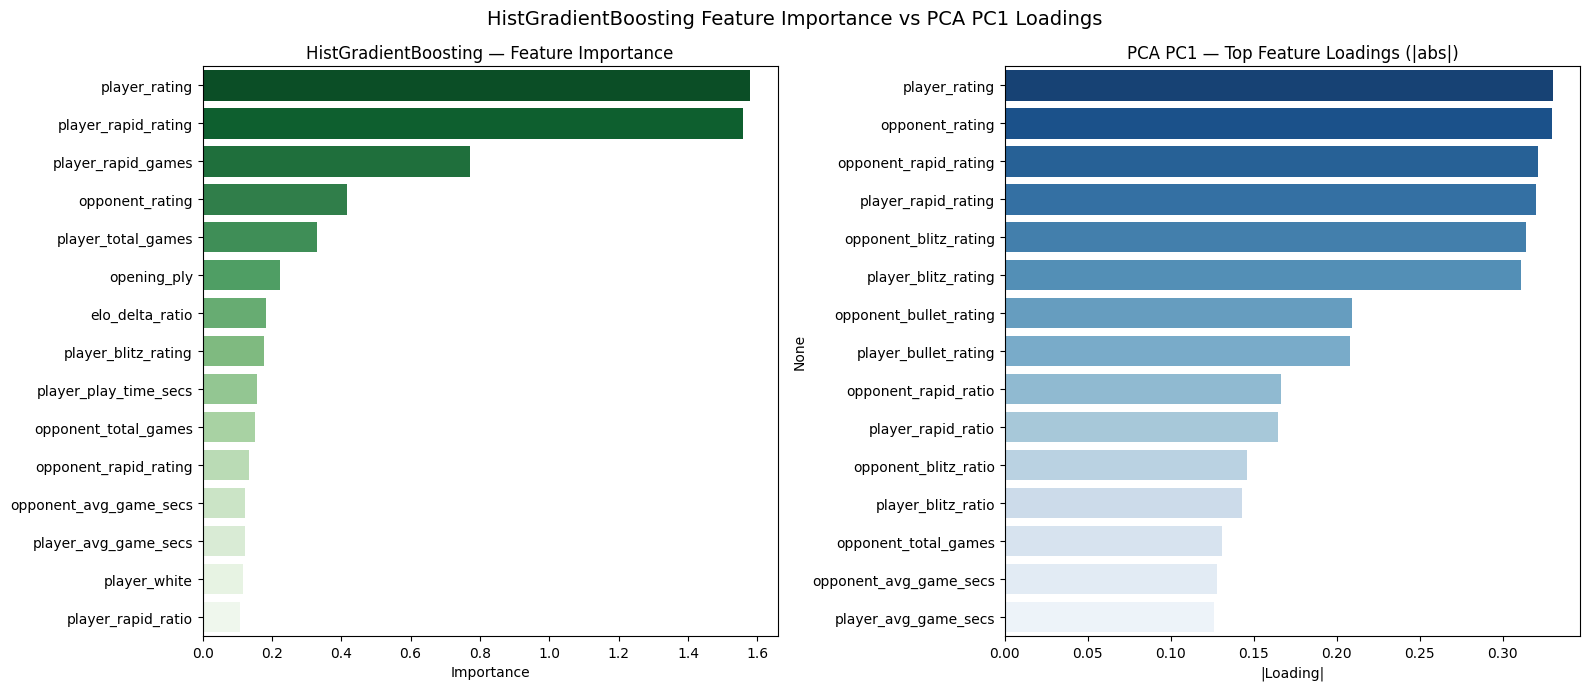

In [24]:
# PCA vs HistGradientBoosting feature importance
imp_pca = SimpleImputer(strategy='median')
X_pca_scaled = StandardScaler().fit_transform(imp_pca.fit_transform(X_train_val))

pca = PCA(n_components=10, random_state=random_state)
pca.fit(X_pca_scaled)

print("Explained variance ratio (top 10 PCs):")
cumvar = 0.0
for i, ev in enumerate(pca.explained_variance_ratio_):
    cumvar += ev
    print(f"  PC{i+1}: {ev:.3f}   cumulative: {cumvar:.3f}")

pc1_abs = pd.Series(np.abs(pca.components_[0]), index=X_train_val.columns).sort_values(ascending=False)

top_n = 15
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sns.barplot(x=fi_df.head(top_n)['importance'].values, y=fi_df.head(top_n)['feature'].values,
            ax=axes[0], palette='Greens_r', hue=fi_df.head(top_n)['feature'].values, legend=False)
axes[0].set_title('HistGradientBoosting — Feature Importance', fontsize=12)
axes[0].set_xlabel('Importance')

sns.barplot(x=pc1_abs.head(top_n).values, y=pc1_abs.head(top_n).index,
            ax=axes[1], palette='Blues_r', hue=pc1_abs.head(top_n).index, legend=False)
axes[1].set_title('PCA PC1 — Top Feature Loadings (|abs|)', fontsize=12)
axes[1].set_xlabel('|Loading|')

plt.suptitle('HistGradientBoosting Feature Importance vs PCA PC1 Loadings', fontsize=14)
plt.tight_layout()
plt.show()

Results: I do not know how to interpret fully these results. Based on PCA and feature importance we can see that rating seems to be important factors.
One important note is that PCA does not include opening_ply (moves according to theory), but GradientBoosting does, maybe it's because it is already somewhat collerated with rating ?.

# Graphs of Distribution

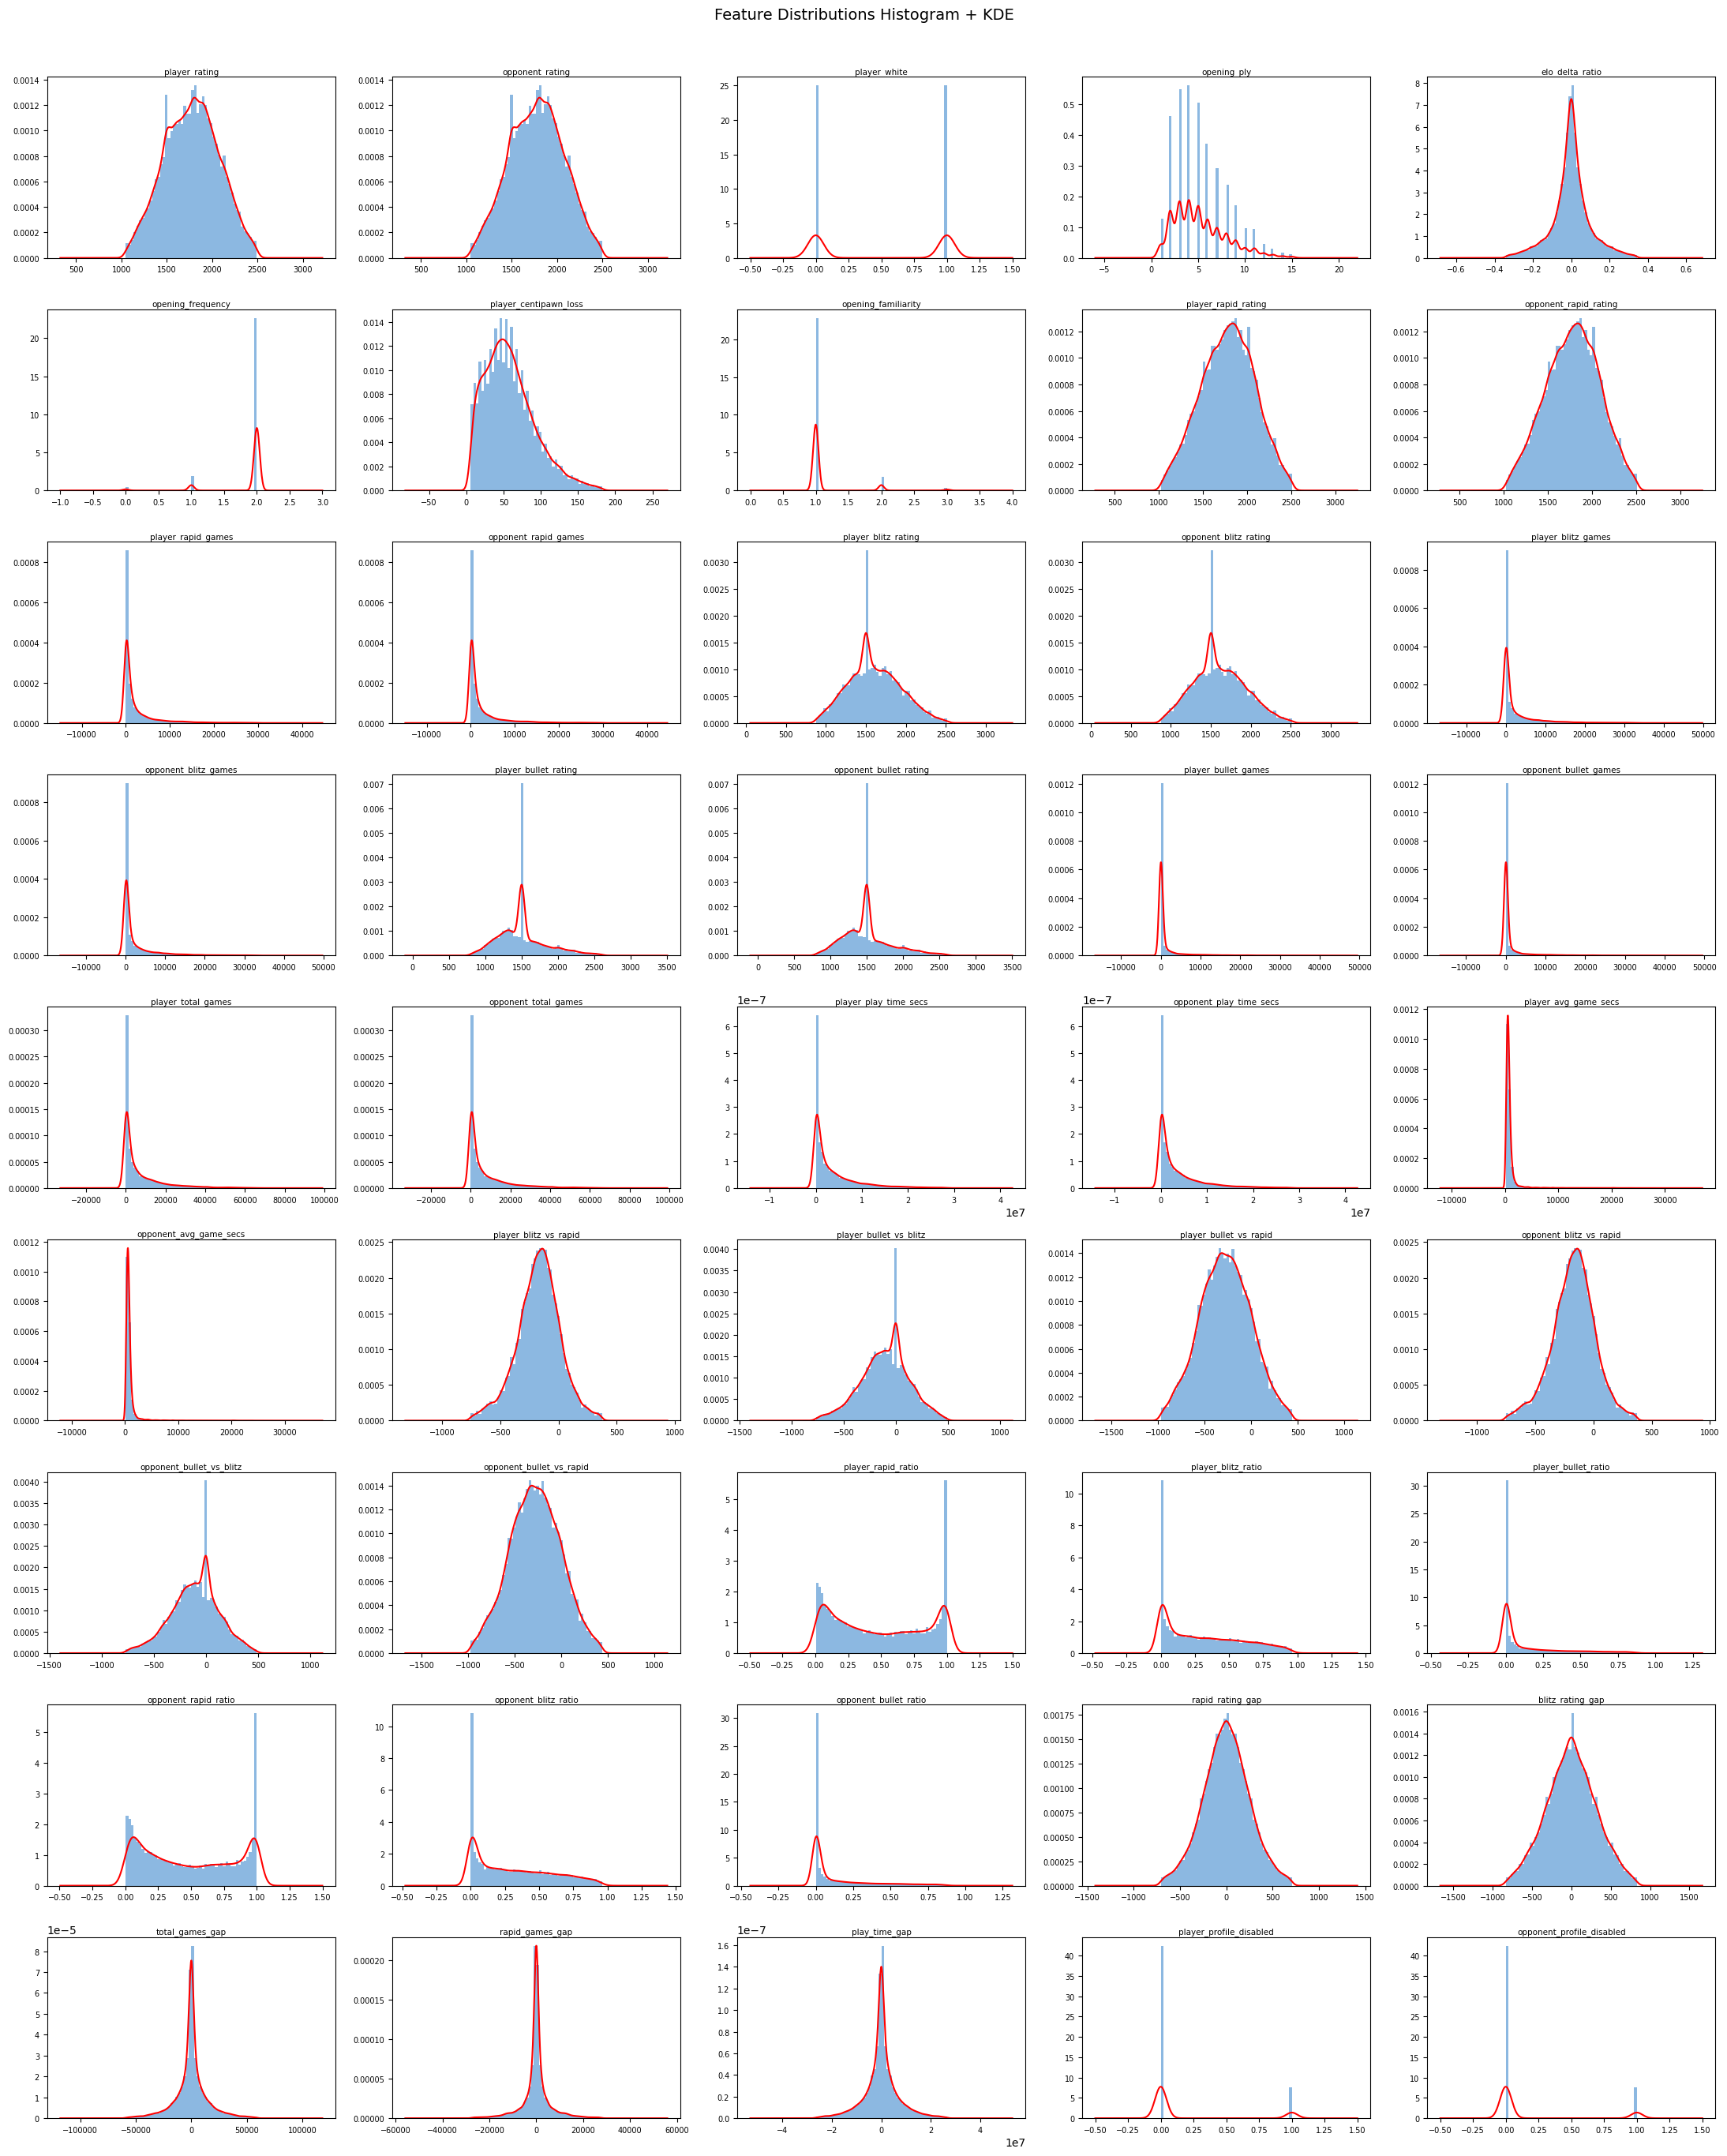

In [25]:
# Distribution (histogram + KDE) for each numeric feature clipped to 1st–99th percentile
numeric_cols_dist = df.select_dtypes(include='number').columns.tolist()

n_cols = 5
n_rows = (len(numeric_cols_dist) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(22, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(numeric_cols_dist):
    data = df[col].dropna()
    lo, hi = data.quantile(0.01), data.quantile(0.99)
    data_clipped = data[(data >= lo) & (data <= hi)]
    data_clipped.hist(bins=50, ax=axes[i], color='#5b9bd5', alpha=0.7, density=True)
    data_clipped.plot.kde(ax=axes[i], color='red', linewidth=1.5)
    axes[i].set_title(col, fontsize=7.5, pad=3)
    axes[i].tick_params(labelsize=7)
    axes[i].set_ylabel('')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Feature Distributions Histogram + KDE', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

'player_rating' => unfirom <br>

 'opponent_rating' => opponent_rating <br>
 'player_white' => class <br>
 'opening_ply' => power law right skewed <br>
 'elo_delta_ratio' => uniform <br>
 'opening_frequency'=> ??? <br>
 'player_centipawn_loss' => power_law right skewed<br>
 'opening_familiarity'=>  <br>
 'player_rapid_rating' => uniform <br>
 'opponent_rapid_rating'=> uniform <br>
 'player_rapid_games'=>power law left skewed <br>
 'opponent_rapid_games' =>power law left skewed <br>
' player_blitz_rating' => roughly uniform <br>
  'opponent_blitz_rating' => roughly uniform  <br>
 'player_blitz_games' => powerlaw right skewed <br>
 'opponent_blitz_games',=> powerlaw right skewed <br>
 'player_bullet_rating' => roughly uniform <br>
 'opponent_bullet_rating' => roughly uniform<br>

 'player_bullet_games' => power laaw right skewed <br>
 'opponent_bullet_games' => power law right skewed <br>
 'player_total_games' => power law right skewed <br>
 'opponent_total_games' => power law right skewed <br>
 'player_play_time_secs' => power law right skewed <br>
 'opponent_play_time_secs' => power law right skewed  <br>
 'player_avg_game_secs' => power law right skewed <br>
'opponent_avg_game_secs' => power law right skewed <br>
       'player_blitz_vs_rapid' => uniform <br>
'player_bullet_vs_blitz' => roughly uniform <br>
       'player_bullet_vs_rapid' => uniform <br>
'opponent_blitz_vs_rapid' => uniform <br>
       'opponent_bullet_vs_blitz' => roughly uniform  <br>
 'opponent_bullet_vs_rapid' => uniform <br>
       'player_rapid_ratio' => U shaped <br>

 'player_blitz_ratio' => Power Law Right skewed <br>
'player_bullet_ratio' => Power Law Right skewed <br>
       'opponent_rapid_ratio' => U shaped <br>

 'opponent_blitz_ratio' Power Law right skewed <br>
 'opponent_bullet_ratio' => power law right skewed <br>
     'rapid_rating_gap' => uniform <br>
'blitz_rating_gap' => uniform <br>
'total_games_gap' => straight spike <br>
     'rapid_games_gap' => straight spike <br>
'play_time_gap' =>straight spike <br>
 'player_profile_disabled' => class <br>
       'opponent_profile_disabled' <br>

We can see that some of the data has almost uniform distribution with a "spike" at 1500 value mark. This probably means that our data has 1500 elo overrepresented.
But also the ELO that new player gets assigned when their account is created is 1500, that may be the reason of the spike.

# Startegy: Scaling based on distribution

In [26]:
#Work on this df: df_original_copy

X = df_original_copy.drop(columns=['player_centipawn_loss'])
y = df_original_copy['player_centipawn_loss']

X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.2, random_state=42)

In [27]:

# Power law right skewed (non-negative) => log1p + StandardScaler
log_std_cols = [
    'opening_ply',
    'player_blitz_games',    'opponent_blitz_games',
    'player_bullet_games',   'opponent_bullet_games',
    'player_total_games',    'opponent_total_games',
    'player_play_time_secs', 'opponent_play_time_secs',
    'player_avg_game_secs',  'opponent_avg_game_secs',
    'player_blitz_ratio',    'player_bullet_ratio',
    'opponent_blitz_ratio',  'opponent_bullet_ratio',
]

# Uniform / roughly normal => StandardScaler
std_cols = [
    'player_rating', 'opponent_rating', 'elo_delta_ratio',
    'player_rapid_rating',  'opponent_rapid_rating',
    'player_blitz_rating',  'opponent_blitz_rating',
    'player_bullet_rating', 'opponent_bullet_rating',
    'player_blitz_vs_rapid',    'player_bullet_vs_blitz',   'player_bullet_vs_rapid',
    'opponent_blitz_vs_rapid',  'opponent_bullet_vs_blitz', 'opponent_bullet_vs_rapid',
    'rapid_rating_gap', 'blitz_rating_gap',
    'opening_frequency', 'opening_familiarity',
]

# U-shaped, left-skewed, spike => MinMaxScaler
minmax_cols = [
    'player_rapid_ratio',  'opponent_rapid_ratio',
    'player_rapid_games',  'opponent_rapid_games',
    'total_games_gap', 'rapid_games_gap', 'play_time_gap',
]

# Binary => passthrough (no scaling needed)
passthrough_cols = ['player_white', 'player_profile_disabled', 'opponent_profile_disabled']

preprocessor_manual = ColumnTransformer([
    ('log_std',  Pipeline([('imp', SimpleImputer(strategy='median')),
                           ('log', FunctionTransformer(np.log1p)),
                           ('scl', StandardScaler())]),  log_std_cols),
    ('std',      Pipeline([('imp', SimpleImputer(strategy='median')),
                           ('scl', StandardScaler())]),  std_cols),
    ('minmax',   Pipeline([('imp', SimpleImputer(strategy='median')),
                           ('scl', MinMaxScaler())]),    minmax_cols),
    ('passthru', 'passthrough',                          passthrough_cols),
])

def make_pipeline(model):
    return Pipeline([
        ('preprocess', preprocessor_manual),
        ('model',   model),
    ])

potential_models = {
    'Dummy':              make_pipeline(DummyRegressor(strategy='mean')),
    'Linear Regression':  make_pipeline(LinearRegression()),
    'Ridge':              make_pipeline(Ridge(alpha=0.1)),
    'Lasso':              make_pipeline(Lasso(alpha=0.1)),
    'ElasticNet':         make_pipeline(ElasticNet(alpha=0.1, l1_ratio=0.5)),
    'KNN (k=10)':         make_pipeline(KNeighborsRegressor(n_neighbors=10)),
    'Decision Tree':      make_pipeline(DecisionTreeRegressor(random_state=random_state)),
    'Random Forest':      make_pipeline(RandomForestRegressor(n_estimators=100, random_state=random_state, n_jobs=-1)),
    'Gradient Boosting':  make_pipeline(HistGradientBoostingRegressor(max_iter=200, random_state=random_state)),
}
results = {}

for name, model_pipeline in potential_models.items():
    scores = cross_val_score(model_pipeline, X_train_val, y_train_val,
                             cv=kf, scoring='neg_root_mean_squared_error')
    rmse = -scores.mean()
    results[name] = {'rmse': rmse}
    print(f"{name:<22}  CV RMSE: {rmse:.2f}")

results_df = pd.DataFrame(results).T.sort_values('rmse')
print("\n--- Ranking ---")
print(results_df.to_string())


Dummy                   CV RMSE: 37.36
Linear Regression       CV RMSE: 34.55
Ridge                   CV RMSE: 34.55
Lasso                   CV RMSE: 34.56
ElasticNet              CV RMSE: 34.62
KNN (k=10)              CV RMSE: 36.04
Decision Tree           CV RMSE: 49.33
Random Forest           CV RMSE: 34.45
Gradient Boosting       CV RMSE: 34.23

--- Ranking ---
                        rmse
Gradient Boosting  34.229319
Random Forest      34.451076
Ridge              34.553142
Linear Regression  34.554156
Lasso              34.564150
ElasticNet         34.621676
KNN (k=10)         36.041956
Dummy              37.359831
Decision Tree      49.331184


Checking distribution of each feature and using appropriate scaler did not improve model significantly (in fact it made it slighly worse)
Two things that I want to try is to try using GridSearch for exploring the model hyperparameters instead of RandomizedSearchCV as relies on randomness and is susceptible to bad luck and check if removing outliers then appriopriate scaling changes the results of model exploration.

BUT IT MADE RIDGE AND LASSO BETTER LETS GO !!!
Lets look at the cell from AP_WorkingOnExpandedDataset: 
                    rmse
Ridge              34.974905 
Linear Regression  34.975004
Lasso              34.976804 

This means that appropriate scaling actually improves linear model (duh)
But still trees models are the best for out use case.

# Strategy: Removing outliers => Scaling based on distribution

In [ ]:
#Remove outliers from above
# Skip binary or flag or target columns, only apply IQR to continuous features
skip_iqr = {'player_white', 'player_profile_disabled', 'opponent_profile_disabled',
            'opening_familiarity', 'opening_frequency', 'player_centipawn_loss'}
iqr_cols = [c for c in df_original_2.select_dtypes(include='number').columns if c not in skip_iqr]

outlier_count = np.zeros(len(df_original_2), dtype=int)
for col in iqr_cols:
    q1, q3 = df_original_2[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    is_out = df_original_2[col].notna() & ~df_original_2[col].between(lo, hi)
    outlier_count += is_out.to_numpy().astype(int)

#what it does is just counting how many features are outliers for each row, then removing rows that have too many outlier features. This way we can keep rows that have a few outlier values but not remove them entirely if they are mostly normal. It's a more flexible way to handle outliers without being too strict on any single feature.
#Also I checked different thresholds 
threshold = 8
mask = outlier_count <= threshold
df_original_2 = df_original_2[mask].reset_index(drop=True)
n_removed = int((~mask).sum())


In [44]:
X = df_original_2.drop(columns=['player_centipawn_loss'])
y = df_original_2['player_centipawn_loss']

X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.2, random_state=42)

In [45]:

# Power law right skewed (non-negative) => log1p + StandardScaler
log_std_cols = [
    'opening_ply',
    'player_blitz_games',    'opponent_blitz_games',
    'player_bullet_games',   'opponent_bullet_games',
    'player_total_games',    'opponent_total_games',
    'player_play_time_secs', 'opponent_play_time_secs',
    'player_avg_game_secs',  'opponent_avg_game_secs',
    'player_blitz_ratio',    'player_bullet_ratio',
    'opponent_blitz_ratio',  'opponent_bullet_ratio',
]

# Uniform / roughly normal => StandardScaler
std_cols = [
    'player_rating', 'opponent_rating', 'elo_delta_ratio',
    'player_rapid_rating',  'opponent_rapid_rating',
    'player_blitz_rating',  'opponent_blitz_rating',
    'player_bullet_rating', 'opponent_bullet_rating',
    'player_blitz_vs_rapid',    'player_bullet_vs_blitz',   'player_bullet_vs_rapid',
    'opponent_blitz_vs_rapid',  'opponent_bullet_vs_blitz', 'opponent_bullet_vs_rapid',
    'rapid_rating_gap', 'blitz_rating_gap',
    'opening_frequency', 'opening_familiarity',
]

# U-shaped, left-skewed, spike => MinMaxScaler
minmax_cols = [
    'player_rapid_ratio',  'opponent_rapid_ratio',
    'player_rapid_games',  'opponent_rapid_games',
    'total_games_gap', 'rapid_games_gap', 'play_time_gap',
]

# Binary => passthrough (no scaling needed)
passthrough_cols = ['player_white', 'player_profile_disabled', 'opponent_profile_disabled']

preprocessor_manual = ColumnTransformer([
    ('log_std',  Pipeline([('imp', SimpleImputer(strategy='median')),
                           ('log', FunctionTransformer(np.log1p)),
                           ('scl', StandardScaler())]),  log_std_cols),
    ('std',      Pipeline([('imp', SimpleImputer(strategy='median')),
                           ('scl', StandardScaler())]),  std_cols),
    ('minmax',   Pipeline([('imp', SimpleImputer(strategy='median')),
                           ('scl', MinMaxScaler())]),    minmax_cols),
    ('passthru', 'passthrough',                          passthrough_cols),
])

def make_pipeline(model):
    return Pipeline([
        ('preprocess', preprocessor_manual),
        ('model',   model),
    ])

potential_models = {
    'Dummy':              make_pipeline(DummyRegressor(strategy='mean')),
    'Linear Regression':  make_pipeline(LinearRegression()),
    'Ridge':              make_pipeline(Ridge(alpha=0.1)),
    'Lasso':              make_pipeline(Lasso(alpha=0.1)),
    'ElasticNet':         make_pipeline(ElasticNet(alpha=0.1, l1_ratio=0.5)),
    'KNN (k=10)':         make_pipeline(KNeighborsRegressor(n_neighbors=10)),
    'Decision Tree':      make_pipeline(DecisionTreeRegressor(random_state=random_state)),
    'Random Forest':      make_pipeline(RandomForestRegressor(n_estimators=100, random_state=random_state, n_jobs=-1)),
    'Gradient Boosting':  make_pipeline(HistGradientBoostingRegressor(max_iter=200, random_state=random_state)),
}
results = {}

for name, model_pipeline in potential_models.items():
    scores = cross_val_score(model_pipeline, X_train_val, y_train_val,
                             cv=kf, scoring='neg_root_mean_squared_error')
    rmse = -scores.mean()
    results[name] = {'rmse': rmse}
    print(f"{name:<22}  CV RMSE: {rmse:.2f}")

results_df = pd.DataFrame(results).T.sort_values('rmse')
print("\n--- Ranking ---")
print(results_df.to_string())


Dummy                   CV RMSE: 37.36
Linear Regression       CV RMSE: 34.55
Ridge                   CV RMSE: 34.55
Lasso                   CV RMSE: 34.56
ElasticNet              CV RMSE: 34.62
KNN (k=10)              CV RMSE: 36.04
Decision Tree           CV RMSE: 49.33
Random Forest           CV RMSE: 34.45
Gradient Boosting       CV RMSE: 34.23

--- Ranking ---
                        rmse
Gradient Boosting  34.229319
Random Forest      34.451076
Ridge              34.553142
Linear Regression  34.554156
Lasso              34.564150
ElasticNet         34.621676
KNN (k=10)         36.041956
Dummy              37.359831
Decision Tree      49.331184


We can also check more combinations, but due to lack of time I'll just stick to the best one I've discovered so far.